# 🌌 Clasificación de Señales de Ondas Gravitacionales con CNN
## Proyecto 19 — Inteligencia Artificial en Física

Notebook unificado: generación parametrizable de señales + arquitectura CNN avanzada en **PyTorch**.

### Estructura
| Bloque | Contenido |
|----|----|
| 0 | Instalación e importaciones |
| 1 | Parámetros globales configurables |
| 2 | Generación de señales, ruido y glitches |
| 3 | Espectrogramas y visualización |
| 4 | Creación del dataset de entrenamiento |
| 5 | Arquitectura CNN avanzada (PyTorch) |
| 6 | Funciones de entrenamiento y evaluación |
| 7 | Entrenamiento con Early Stopping |
| 8 | Curvas de aprendizaje |
| 9 | Evaluación: ROC y Matriz de Confusión |
| 10 | Sensibilidad vs SNR |
| 11 | Guardado y carga del modelo |
| 12 | Dataset de prueba con parámetros aleatorios (spin, etc.) |
| 13 | Test de generalización |


## Bloque 0 — Instalación e Importaciones

In [ ]:
# Descomenta si necesitas instalar las dependencias
!pip install pycbc lalsuite torch torchvision scikit-learn scipy matplotlib seaborn

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import random
import copy
import os
from google.colab import files

from scipy import signal as sp_signal
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

try:
    from pycbc.waveform import get_td_waveform
    PYCBC_AVAILABLE = True
    print("✅  PyCBC disponible — se usarán formas de onda físicas (IMRPhenomD / TaylorT4).")
except ImportError:
    PYCBC_AVAILABLE = False
    print("⚠️  PyCBC NO disponible — se usarán chirps sintéticos como fallback.")

device = torch.device(
    "cuda"  if torch.cuda.is_available()       else
    "mps"   if torch.backends.mps.is_available() else
    "cpu"
)
print(f"🖥️  Dispositivo PyTorch: {device}")

def set_all_seeds(seed=42):
    """Fija todas las semillas para reproducibilidad total."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(42)
print("✅ Semillas fijadas para reproducibilidad")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 135.1 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
ERROR: pip's dependency resolve

/usr/lib/python3.12/importlib/__init__.py:90: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)


✅  PyCBC disponible — se usarán formas de onda físicas (IMRPhenomD / TaylorT4).
🖥️  Dispositivo PyTorch: cuda
✅ Semillas fijadas para reproducibilidad


## Bloque 1 — Parámetros Globales Configurables

Todos los hiperparámetros físicos y del modelo se definen aquí.
Modifica este diccionario para explorar distintos regímenes sin tocar el resto del código.

In [ ]:
# ══════════════════════════════════════════════════════════════
#  PARÁMETROS GLOBALES — edita aquí para cambiar cualquier cosa
# ══════════════════════════════════════════════════════════════

PARAMS = {
    # ── Parámetros de tiempo / muestreo ──────────────────────
    "delta_t"       : 1.0 / 2048,   # Paso temporal [s]  (fs = 2048 Hz)
    "window_min"    : 1.0,           # Duración mínima de ventana [s]
    "window_max"    : 2.0,           # Duración máxima de ventana [s]

    # ── Ruido detector ───────────────────────────────────────
    "sigma_min"     : 1e-23,         # Amplitud mínima del ruido gaussiano
    "sigma_max"     : 1e-21,         # Amplitud máxima del ruido gaussiano
    "glitch_prob"   : 0.50,          # Probabilidad de añadir glitch al ruido

    # ── Señal gravitacional ──────────────────────────────────
    "snr_min"       : 5.0,           # SNR mínimo de inyección
    "snr_max"       : 20.0,          # SNR máximo de inyección
    "d_min"         : 100.0,         # Distancia mínima [Mpc]
    "d_max"         : 1000.0,        # Distancia máxima [Mpc]
    "f_lower_min"   : 40.0,          # Frecuencia de corte inferior mínima [Hz]
    "f_lower_max"   : 60.0,          # Frecuencia de corte inferior máxima [Hz]

    # ── Masas (rangos por tipo de sistema) ───────────────────
    "m_ns_min"      : 1.2,           # Masa mínima estrella de neutrones [M☉]
    "m_ns_max"      : 2.0,           # Masa máxima estrella de neutrones [M☉]
    "m_bh_min"      : 10.0,          # Masa mínima agujero negro [M☉]
    "m_bh_max"      : 50.0,          # Masa máxima agujero negro [M☉]
    "m_nsbh_bh_min" : 8.0,           # Masa mínima BH en sistema NSBH [M☉]
    "m_nsbh_bh_max" : 30.0,          # Masa máxima BH en sistema NSBH [M☉]

    # ── Spin ─────────────────────────────────────────────────
    "spin_min"      : -0.8,          # Componente z de spin alineado mínimo (adimensional)
    "spin_max"      :  0.8,          # Componente z de spin alineado máximo (adimensional)
    "use_spin"      : True,          # Activar/desactivar parámetros de spin

    # ── Glitch ───────────────────────────────────────────────
    "glitch_f_min"  : 30.0,          # Frecuencia mínima de glitches [Hz]
    "glitch_f_max"  : 300.0,         # Frecuencia máxima de glitches [Hz]
    "glitch_Q_min"  : 3.0,           # Factor Q mínimo (sine-gaussian)
    "glitch_Q_max"  : 20.0,          # Factor Q máximo (sine-gaussian)
    "glitch_snr_min": 5.0,           # SNR mínimo del glitch inyectado
    "glitch_snr_max": 20.0,          # SNR máximo del glitch inyectado

    # ── Espectrograma ─────────────────────────────────────────
    "nperseg"       : 64,            # Muestras por segmento de STFT
    "noverlap"      : 32,            # Solapamiento entre segmentos

    # ── Dataset ──────────────────────────────────────────────
    "n_samples"       : 10000,          # Muestras para entrenamiento+val+test # Pongo 500 para pruebas. Luego hay que subir para 2000
    "test_size"     : 0.15,          # Fracción de test
    "val_size"      : 0.15,          # Fracción de validación (sobre el total)

    # ── Entrenamiento ─────────────────────────────────────────
    "batch_size"    : 64,
    "lr"            : 5e-5,
    "patience"      : 10,            # Early stopping
    "dropout1"      : 0.50,          # Dropout primera capa FC
    "dropout2"      : 0.30,          # Dropout segunda capa FC
}

FS = int(1.0 / PARAMS["delta_t"])   # Frecuencia de muestreo [Hz]
print(f"Configuración cargada. fs = {FS} Hz | n_samples = {PARAMS['n_samples']} muestras")


Configuración cargada. fs = 2048 Hz | n_samples = 10000 muestras


## Bloque 2 — Generación de Señales, Ruido y Glitches

In [ ]:
# ──────────────────────────────────────────────────────────────
#  Fallback sintético si PyCBC no está disponible
# ──────────────────────────────────────────────────────────────

def synthetic_chirp(delta_t, window_duration, snr, f_start=30.0, f_end=300.0, sigma=1e-21):
    """Chirp sintético cuadrático que imita la barrida frecuencial de un merger."""
    N = int(window_duration / delta_t)
    t = np.linspace(0, window_duration, N)
    chirp = sp_signal.chirp(t, f0=f_start, f1=f_end, t1=window_duration, method='quadratic')
    # Ventana de Tukey para suavizar bordes
    chirp *= sp_signal.windows.tukey(N, alpha=0.2)
    chirp /= (np.std(chirp) + 1e-12)

    noise = np.random.normal(0, sigma, N)
    return t, noise + snr * sigma * chirp


# ──────────────────────────────────────────────────────────────
#  Glitch
# ──────────────────────────────────────────────────────────────

def generate_glitch(times, sigma=1e-21, p=PARAMS):
    """Genera una anomalía instrumental (glitch) aleatorizada."""
    t_norm = (times - times[0]) / (times[-1] - times[0] + 1e-10)

    glitch_type = np.random.choice(["sine_gaussian", "blip", "band_limited"])

    if glitch_type == "sine_gaussian":
        f0  = np.random.uniform(p["glitch_f_min"], p["glitch_f_max"])
        tau = 0.1
        glitch = (np.exp(-((t_norm - 0.5)**2) / (2 * tau**2))
                  * np.sin(2 * np.pi * f0 * t_norm))

    elif glitch_type == "blip":
        center = np.random.uniform(0.3, 0.7)
        width  = np.random.uniform(0.01, 0.05)
        glitch = np.exp(-((t_norm - center)**2) / (2 * width**2))

    else:  # band_limited
        freq   = np.random.uniform(50, 400)
        glitch = np.sin(2 * np.pi * freq * t_norm) * np.random.randn(len(t_norm)) * 0.2

    snr_g  = np.random.uniform(p["glitch_snr_min"], p["glitch_snr_max"])
    glitch = glitch / (np.std(glitch) + 1e-12) * sigma * snr_g
    return glitch


# ──────────────────────────────────────────────────────────────
#  Ruido detector
# ──────────────────────────────────────────────────────────────

def generate_noise(times, sigma=1e-21, add_glitch=False, p=PARAMS):
    """Ruido gaussiano con opción de inyectar un glitch."""
    noise = np.random.normal(0.0, sigma, len(times))
    if add_glitch:
        noise += generate_glitch(times, sigma, p)
    return times, noise


# ──────────────────────────────────────────────────────────────
#  Onda gravitacional con parámetros físicos completos
# ──────────────────────────────────────────────────────────────

def generate_wave(system_type=None, distance=500, delta_t=None,
                  f_lower=20, zero_cut=True, target_snr=10.0,
                  window_duration=None, spin1z=0.0, spin2z=0.0,
                  use_spin=None, polarization_mix=False, p=PARAMS):

    if delta_t is None:
        delta_t = p["delta_t"]
    if use_spin is None:
        use_spin = p["use_spin"]
    # ── VENTANA FIJA: nunca más de window_max ─────────────────
    if window_duration is None:
        window_duration = random.uniform(p["window_min"], p["window_max"])
    window_duration = min(window_duration, p["window_max"])  # <-- LÍNEA CLAVE

    if system_type is None:
        system_type = np.random.choice(["BNS", "BBH", "NSBH"])

    if system_type == "BNS":
        m1 = np.random.uniform(p["m_ns_min"], p["m_ns_max"])
        m2 = np.random.uniform(p["m_ns_min"], p["m_ns_max"])
        approximant = "TaylorT4" if not use_spin else "IMRPhenomD"
    elif system_type == "BBH":
        m1 = np.random.uniform(p["m_bh_min"], p["m_bh_max"])
        m2 = np.random.uniform(p["m_bh_min"], p["m_bh_max"])
        approximant = "IMRPhenomD"
    else:  # NSBH
        m1 = np.random.uniform(p["m_ns_min"], p["m_ns_max"])
        m2 = np.random.uniform(p["m_nsbh_bh_min"], p["m_nsbh_bh_max"])
        approximant = "IMRPhenomD"

    if not PYCBC_AVAILABLE:
        return synthetic_chirp(
            delta_t, window_duration, target_snr,
            f_start=f_lower, sigma=p["sigma_min"]
        )

    try:
        kwargs = dict(approximant=approximant, mass1=m1, mass2=m2,
                      distance=distance, delta_t=delta_t, f_lower=f_lower)
        if use_spin:
            kwargs.update(spin1z=spin1z, spin2z=spin2z)

        hp, hc = get_td_waveform(**kwargs)

        times = np.array(hp.sample_times)
        h_arr = np.array(hp)

        if polarization_mix:
            theta = np.random.uniform(0, 2 * np.pi)
            h_arr = np.cos(theta) * h_arr + np.sin(theta) * np.array(hc)

        if zero_cut:
            h_arr = h_arr[times <= 0.0]

    except Exception:
        return generate_wave(system_type=None, distance=distance, delta_t=delta_t,
                             f_lower=f_lower, zero_cut=zero_cut, target_snr=target_snr,
                             window_duration=window_duration, spin1z=spin1z, spin2z=spin2z,
                             use_spin=use_spin, polarization_mix=polarization_mix, p=p)

    # ── TRUNCAR la señal a la ventana fija (en vez de expandir) ──
    N_win = int(window_duration / delta_t)
    if len(h_arr) > N_win:
        h_arr = h_arr[-N_win:]   # quedarse con el merger (parte final)

    # ── SNR → sigma del ruido ─────────────────────────────────
    energia   = np.sqrt(np.sum(h_arr**2))
    sigma_calc = energia / target_snr if target_snr > 0 else 1e-15

    # ── Ventana de ruido de tamaño fijo ───────────────────────
    t_win  = np.arange(N_win) * delta_t
    _, noise = generate_noise(t_win, sigma=sigma_calc, add_glitch=False, p=p)

    # ── Inyección aleatoria ───────────────────────────────────
    h_noisy   = noise.copy()
    max_start = max(1, N_win - len(h_arr))
    start_idx = np.random.randint(0, max_start)
    h_noisy[start_idx: start_idx + len(h_arr)] += h_arr

    return t_win, h_noisy


print("✅  Funciones de generación definidas.")


✅  Funciones de generación definidas.


## Bloque 3 — Espectrograma y Visualización Comparativa

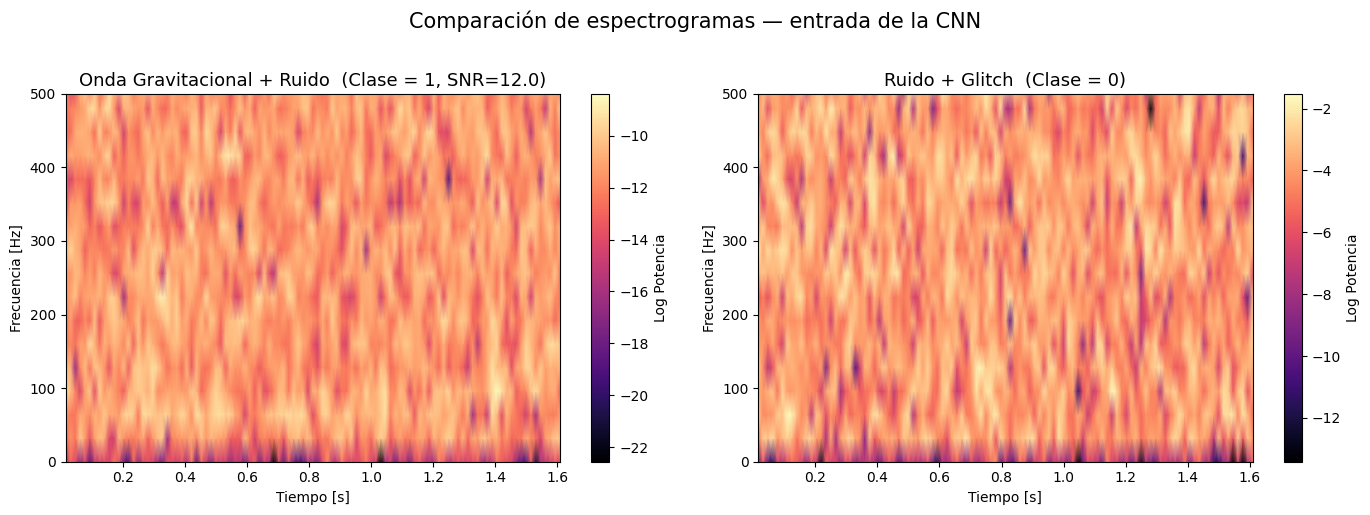

Forma del espectrograma (f x t): (33, 103)


In [ ]:
def get_spectrogram(data, fs=FS, p=PARAMS):
    """
    Calcula el espectrograma logarítmico de la señal.
    Devuelve (f, t_spec, log_Sxx).
    """
    data_scaled = np.array(data) * 1e21          # reescalado para evitar underflow
    f, t_s, Sxx = sp_signal.spectrogram(
        data_scaled, fs=fs,
        nperseg=p["nperseg"], noverlap=p["noverlap"]
    )
    return f, t_s, np.log(Sxx + 1e-10)


# ── Generamos un ejemplo de cada clase ──────────────────────
snr_demo = 12.0 #  para pruebas poner 100. despues cambiar a 12

# Clase 1: señal + ruido
t_gw, gw_data = generate_wave(target_snr=snr_demo)
f_gw, t_sg, spec_gw = get_spectrogram(gw_data)

# Clase 0: solo ruido (con o sin glitch)
n_samples_noise = len(t_gw)
t_noise = np.arange(n_samples_noise) * PARAMS["delta_t"]
_, noise_data = generate_noise(t_noise, sigma=1e-21, add_glitch=True)
f_no, t_sn, spec_no = get_spectrogram(noise_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].pcolormesh(t_sg, f_gw, spec_gw, shading='gouraud', cmap='magma')
axes[0].set_title(f"Onda Gravitacional + Ruido  (Clase = 1, SNR={snr_demo})", fontsize=13)
axes[0].set_xlabel("Tiempo [s]")
axes[0].set_ylabel("Frecuencia [Hz]")
axes[0].set_ylim(0, 500)
plt.colorbar(im0, ax=axes[0], label='Log Potencia')

im1 = axes[1].pcolormesh(t_sn, f_no, spec_no, shading='gouraud', cmap='magma')
axes[1].set_title("Ruido + Glitch  (Clase = 0)", fontsize=13)
axes[1].set_xlabel("Tiempo [s]")
axes[1].set_ylabel("Frecuencia [Hz]")
axes[1].set_ylim(0, 500)
plt.colorbar(im1, ax=axes[1], label='Log Potencia')

plt.suptitle("Comparación de espectrogramas — entrada de la CNN", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()
print("Forma del espectrograma (f x t):", spec_gw.shape)


## Bloque 4 — Creación del Dataset de Entrenamiento

In [ ]:
def create_dataset(n_elements, p=PARAMS, verbose=True):
    """
    Genera n_elements espectrogramas etiquetados (50% señal, 50% ruido).
    Todos los parámetros físicos se muestrean aleatoriamente dentro de los
    rangos definidos en PARAMS.

    Devuelve X_array (N, H, W_max, 1)  y  y_array (N, 1).
    """
    if verbose:
        print(f"Generando dataset de {n_elements} muestras...")

    n_ruido  = n_elements // 2
    n_senal  = n_elements - n_ruido
    X_list, y_list = [], []
    fs = FS

    # ── Clase 0: Ruido (±glitch) ──────────────────────────────
    for i in range(n_ruido):
        t_rand   = random.uniform(p["window_min"], p["window_max"])
        sig_rand = random.uniform(p["sigma_min"],  p["sigma_max"])
        N_samp   = int(t_rand / p["delta_t"])
        times    = np.arange(N_samp) * p["delta_t"]

        add_gl   = np.random.rand() < p["glitch_prob"]
        _, noise = generate_noise(times, sigma=sig_rand, add_glitch=add_gl, p=p)

        _, _, spec = get_spectrogram(noise, fs=fs, p=p)
        X_list.append(np.expand_dims(spec, axis=-1))
        y_list.append(0)

        if verbose and (i + 1) % max(1, n_ruido // 5) == 0:
            print(f"  Ruido: {i+1}/{n_ruido}")

    # ── Clase 1: Señal + Ruido ────────────────────────────────
    for i in range(n_senal):
        snr  = random.uniform(p["snr_min"],     p["snr_max"])
        d    = random.uniform(p["d_min"],       p["d_max"])
        f0   = random.uniform(p["f_lower_min"], p["f_lower_max"])
        s1z  = random.uniform(p["spin_min"],    p["spin_max"]) if p["use_spin"] else 0.0
        s2z  = random.uniform(p["spin_min"],    p["spin_max"]) if p["use_spin"] else 0.0

        _, wave = generate_wave(
            distance=d, f_lower=f0, target_snr=snr,
            delta_t=p["delta_t"], spin1z=s1z, spin2z=s2z,
            use_spin=p["use_spin"], p=p
        )
        _, _, spec = get_spectrogram(wave, fs=fs, p=p)
        X_list.append(np.expand_dims(spec, axis=-1))
        y_list.append(1)

        if verbose and (i + 1) % max(1, n_senal // 5) == 0:
            print(f"  Señal: {i+1}/{n_senal}")

    # ── Mezcla y padding 2D ───────────────────────────────────
    combined = list(zip(X_list, y_list))
    random.shuffle(combined)
    X_list, y_list = zip(*combined)

    fixed_h = X_list[0].shape[0]
    max_w   = max(s.shape[1] for s in X_list)

    if verbose:
        print(f"Dimensión espectrogramas: alto={fixed_h}, ancho_max={max_w}")

    X_array = np.zeros((len(X_list), fixed_h, max_w, 1), dtype='float32')
    for i, spec in enumerate(X_list):
        h, w, _ = spec.shape
        X_array[i, :h, :w, :] = spec

    y_array = np.array(y_list, dtype='float32').reshape(-1, 1)
    return X_array, y_array


# ── Crear dataset principal ───────────────────────────────────
X_all, y_all = create_dataset(PARAMS["n_samples"])

# ── Splits: train / val / test ────────────────────────────────
test_frac = PARAMS["test_size"]
val_frac  = PARAMS["val_size"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=test_frac, stratify=y_all, random_state=42
)
val_frac_adj = val_frac / (1.0 - test_frac)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_frac_adj, stratify=y_temp, random_state=42
)

# ── Normalización (media y std del train) ─────────────────────
#mean_tr = X_train.mean()
#std_tr  = X_train.std() + 1e-8
#X_train = (X_train - mean_tr) / std_tr
#X_val   = (X_val   - mean_tr) / std_tr
#X_test  = (X_test  - mean_tr) / std_tr
def normalize_subset(data):
    mean_val = np.mean(data)
    std_val = np.std(data)
    # Sumamos 1e-10 a std para evitar divisiones por cero si hay un error en los datos
    return (data - mean_val) / (std_val + 1e-10)
X_train=normalize_subset(X_train)
X_val=normalize_subset(X_val)
X_test=normalize_subset(X_test)

# ── Tensores PyTorch (N, C=1, H, W) ──────────────────────────
def to_tensor(X, y):
    Xt = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2)
    yt = torch.tensor(y, dtype=torch.float32)
    return Xt, yt

X_tr_t, y_tr_t = to_tensor(X_train, y_train)
X_vl_t, y_vl_t = to_tensor(X_val,   y_val)
X_te_t, y_te_t = to_tensor(X_test,  y_test)

bs = PARAMS["batch_size"]
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=bs, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_vl_t, y_vl_t), batch_size=bs)
test_loader  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=bs)

print(f"\nTrain: {X_train.shape[0]}  |  Val: {X_val.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Forma entrada CNN: {X_tr_t.shape[1:]}")


Generando dataset de 10000 muestras...
  Ruido: 1000/5000
  Ruido: 2000/5000
  Ruido: 3000/5000
  Ruido: 4000/5000
  Ruido: 5000/5000
  Señal: 1000/5000
  Señal: 2000/5000
  Señal: 3000/5000
  Señal: 4000/5000
  Señal: 5000/5000
Dimensión espectrogramas: alto=33, ancho_max=126

Train: 7000  |  Val: 1500  |  Test: 1500
Forma entrada CNN: torch.Size([1, 33, 126])


In [ ]:
print("=== DIAGNÓSTICO ===")
print(f"Total muestras: {len(X_all)}")
print(f"Train: {len(X_train)}")
print(f"Val: {len(X_val)}")
print(f"Test: {len(X_test)}")

# Verificar que val es fijo
print(f"\nPrimera muestra de validación (índice 0):")
print(f"  Forma: {X_val[0].shape}")
print(f"  Hash: {hash(X_val[0].tobytes())}")
print("\n(Este hash debe ser idéntico si ejecutas esta celda varias veces)")

# Verificar distribución de clases
print(f"\nDistribución en validación:")
print(f"  Clase 0 (ruido): {(y_val == 0).sum()}")
print(f"  Clase 1 (señal): {(y_val == 1).sum()}")

=== DIAGNÓSTICO ===
Total muestras: 10000
Train: 7000
Val: 1500
Test: 1500

Primera muestra de validación (índice 0):
  Forma: (33, 126, 1)
  Hash: -5237123488310126185

(Este hash debe ser idéntico si ejecutas esta celda varias veces)

Distribución en validación:
  Clase 0 (ruido): 750
  Clase 1 (señal): 750


## Bloque 5 — Arquitectura CNN Avanzada (PyTorch)

In [ ]:
class GravWaveCNN(nn.Module):
    """
    Red convolucional para clasificación de espectrogramas de ondas gravitacionales.

    Arquitectura:
      Conv2d → BatchNorm → ReLU → MaxPool  (x3, filtros crecientes)
      Conv2d → BatchNorm → ReLU            (capa extra sin pooling)
      AdaptiveAvgPool2d(1)                 (equivalente a GlobalAveragePooling)
      Linear → ReLU → Dropout
      Linear → ReLU → Dropout
      Linear → Sigmoid                     (probabilidad clase 1)
    """

    def __init__(self, dropout1=0.5, dropout2=0.3):
        super().__init__()

        # ── Bloque convolucional ──────────────────────────────
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(1,  32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Bloque 4 (sin pooling — preserva resolución)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        # ── Global Average Pooling → vector fijo de 256 ───────
        self.gap = nn.AdaptiveAvgPool2d(1)

        # ── Clasificador FC ───────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout1),

            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout2),

            nn.Linear(64, 1),
            nn.Sigmoid()            # salida en [0,1] → probabilidad
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return self.classifier(x)


# ── Instanciar modelo ─────────────────────────────────────────
model = GravWaveCNN(
    dropout1=PARAMS["dropout1"],
    dropout2=PARAMS["dropout2"]
).to(device)

# Resumen rápido
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nParámetros totales:      {total_params:,}")
print(f"Parámetros entrenables:  {train_params:,}")


GravWaveCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, 

## Bloque 6 — Funciones de Entrenamiento y Evaluación

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds_prob = model(X_batch)
        loss = criterion(preds_prob, y_batch)
        loss.backward()

        # ── Gradient clipping: evita explosión de gradientes ──
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds_bin   = (preds_prob >= 0.5).float()
        correct    += (preds_bin == y_batch).sum().item()
        total      += y_batch.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            probs  = model(X_batch)
            loss   = criterion(probs, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds_bin   = (probs >= 0.5).float()
            correct    += (preds_bin == y_batch).sum().item()
            total      += y_batch.size(0)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    return (total_loss / total, correct / total,
            np.array(all_probs).ravel(), np.array(all_labels).ravel())


print("✅  Funciones de entrenamiento definidas (con gradient clipping).")

✅  Funciones de entrenamiento definidas (con gradient clipping).


## Bloque 7 — Entrenamiento con Early Stopping

In [ ]:
epochs=14
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=PARAMS["lr"])  # Se puede añadir weight decay = 1e-4
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

history = {k: [] for k in ("loss", "val_loss", "acc", "val_acc")}
best_val_loss = float('inf')
best_weights  = copy.deepcopy(model.state_dict())
patience_ctr  = 0

print(f"Entrenando {epochs} épocas máximo (patience={PARAMS['patience']})...")
print("-" * 65)

print("\nVerificando que validation set es fijo...")
first_batch_val = next(iter(val_loader))
val_hash = hash(first_batch_val[0].cpu().numpy().tobytes())
print(f"Hash del primer batch de validación: {val_hash}")
print("(Este valor debe ser idéntico en cada ejecución del notebook)\n")

for epoch in range(epochs):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(vl_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history["loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    marker = ""
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_weights  = copy.deepcopy(model.state_dict())
        patience_ctr  = 0
        marker = " ◀ best"
    else:
        patience_ctr += 1

    print(f"Epoch {epoch+1:3d} | "
          f"loss={tr_loss:.4f}  acc={tr_acc:.4f} | "
          f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f} | "
          f"lr={current_lr:.2e}{marker}")

    if patience_ctr >= PARAMS["patience"]:
        print(f"\nEarly stopping en época {epoch+1}.")
        break

model.load_state_dict(best_weights)

te_loss, te_acc, te_probs, te_labels = evaluate(model, test_loader, criterion, device)
print(f"\n{'='*65}")
print(f"  ✅  Accuracy en TEST: {te_acc*100:.2f}%")
print(f"{'='*65}")

Entrenando 14 épocas máximo (patience=10)...
-----------------------------------------------------------------

Verificando que validation set es fijo...
Hash del primer batch de validación: -182264510678715631
(Este valor debe ser idéntico en cada ejecución del notebook)

Epoch   1 | loss=0.6181  acc=0.7090 | val_loss=0.5735  val_acc=0.7087 | lr=5.00e-05 ◀ best
Epoch   2 | loss=0.5601  acc=0.7273 | val_loss=0.5254  val_acc=0.7367 | lr=5.00e-05 ◀ best
Epoch   3 | loss=0.5218  acc=0.7413 | val_loss=0.4917  val_acc=0.7380 | lr=5.00e-05 ◀ best
Epoch   4 | loss=0.5010  acc=0.7520 | val_loss=0.4806  val_acc=0.7440 | lr=5.00e-05 ◀ best
Epoch   5 | loss=0.4794  acc=0.7581 | val_loss=0.4583  val_acc=0.7520 | lr=5.00e-05 ◀ best
Epoch   6 | loss=0.4636  acc=0.7679 | val_loss=0.4510  val_acc=0.7593 | lr=5.00e-05 ◀ best
Epoch   7 | loss=0.4566  acc=0.7677 | val_loss=0.4371  val_acc=0.7813 | lr=5.00e-05 ◀ best
Epoch   8 | loss=0.4390  acc=0.7819 | val_loss=0.4218  val_acc=0.7813 | lr=5.00e-05 ◀ bes

## Bloque 8 — Curvas de Aprendizaje

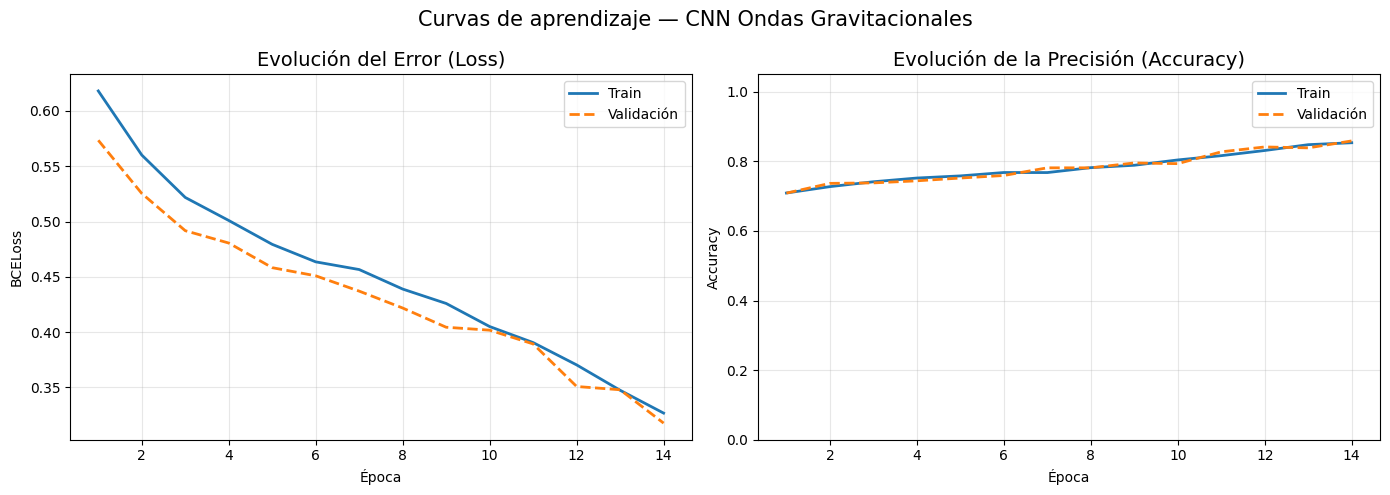

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep_range = range(1, len(history["loss"]) + 1)

axes[0].plot(ep_range, history["loss"],     label="Train",      lw=2)
axes[0].plot(ep_range, history["val_loss"],  label="Validación", lw=2, linestyle='--')
axes[0].set_title("Evolución del Error (Loss)", fontsize=14)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("BCELoss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, history["acc"],     label="Train",      lw=2)
axes[1].plot(ep_range, history["val_acc"],  label="Validación", lw=2, linestyle='--')
axes[1].set_title("Evolución de la Precisión (Accuracy)", fontsize=14)
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Curvas de aprendizaje — CNN Ondas Gravitacionales", fontsize=15)
plt.tight_layout()
plt.show()


## Bloque 9 — Evaluación: ROC y Matriz de Confusión

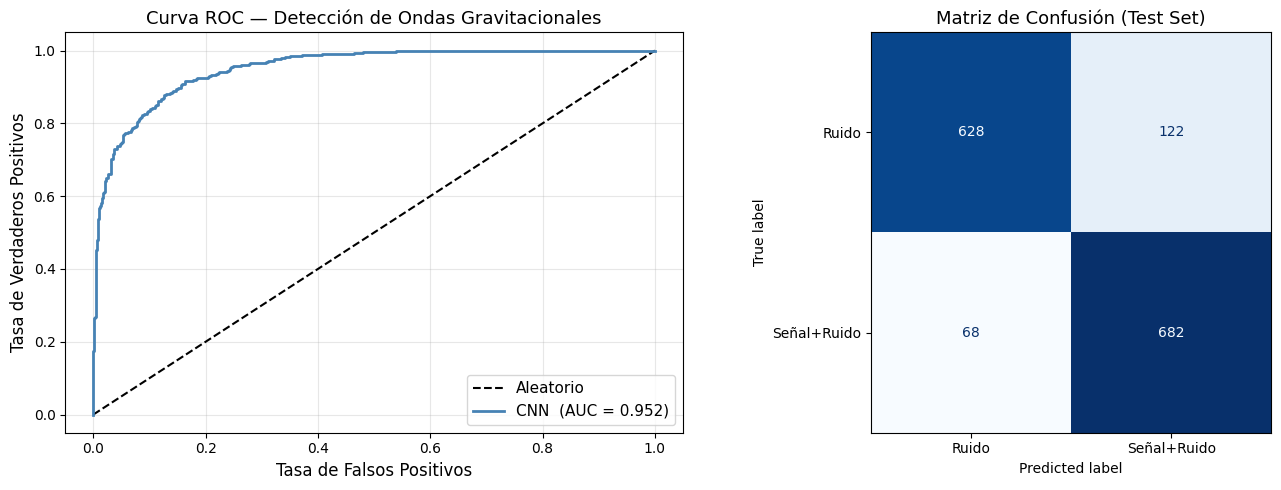


--- REPORTE DETALLADO (Test Set) ---
                 precision    recall  f1-score   support

      Ruido (0)       0.90      0.84      0.87       750
Señal+Ruido (1)       0.85      0.91      0.88       750

       accuracy                           0.87      1500
      macro avg       0.88      0.87      0.87      1500
   weighted avg       0.88      0.87      0.87      1500



In [ ]:
# ── ROC ──────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(te_labels, te_probs)
auc_score   = auc(fpr, tpr)

# ── Confusion Matrix ──────────────────────────────────────────
y_pred_bin = (te_probs >= 0.5).astype(int)
cm = confusion_matrix(te_labels.astype(int), y_pred_bin)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot([0, 1], [0, 1], 'k--', label='Aleatorio')
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'CNN  (AUC = {auc_score:.3f})')
axes[0].set_xlabel('Tasa de Falsos Positivos', fontsize=12)
axes[0].set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
axes[0].set_title('Curva ROC — Detección de Ondas Gravitacionales', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Confusion Matrix
disp = ConfusionMatrixDisplay(cm, display_labels=["Ruido", "Señal+Ruido"])
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión (Test Set)', fontsize=13)

plt.tight_layout()
plt.show()

# Reporte detallado
print("\n--- REPORTE DETALLADO (Test Set) ---")
print(classification_report(
    te_labels.astype(int), y_pred_bin,
    target_names=["Ruido (0)", "Señal+Ruido (1)"]
))


## Bloque 10 — Sensibilidad vs SNR

Calibrando ruido de fondo de forma autónoma...

Evaluando Exactitud (Accuracy) por nivel de SNR...
  SNR =   1.0 → Exactitud = 47.0%
  SNR =   2.0 → Exactitud = 47.0%
  SNR =   4.0 → Exactitud = 53.0%
  SNR =   6.0 → Exactitud = 54.0%
  SNR =   8.0 → Exactitud = 63.0%
  SNR =  10.0 → Exactitud = 65.0%
  SNR =  15.0 → Exactitud = 77.0%
  SNR =  20.0 → Exactitud = 83.0%
  SNR =  30.0 → Exactitud = 82.0%
  SNR =  50.0 → Exactitud = 81.0%
  SNR = 100.0 → Exactitud = 87.0%


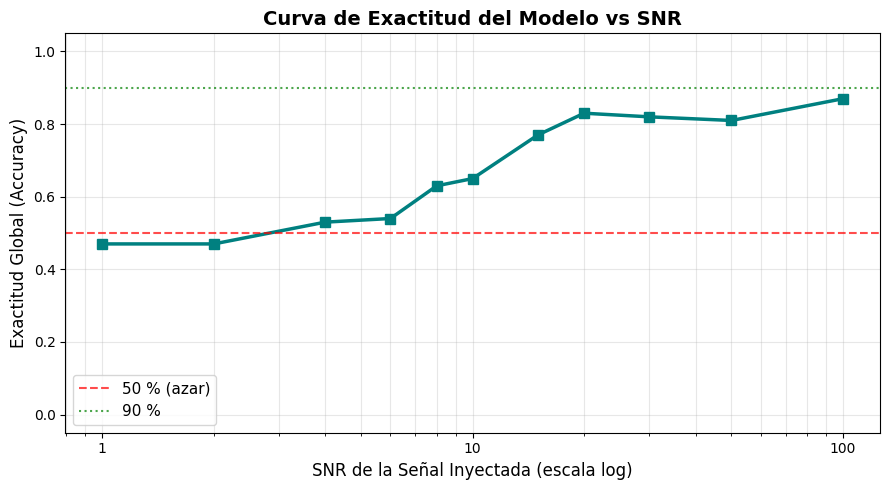

In [ ]:
## Bloque 10 — Exactitud (Accuracy) vs SNR

def get_dynamic_noise_calibration(n_samples=200, p=PARAMS):
    """
    Genera ruido puro para extraer la media y desviación estándar del fondo.
    Esto permite que la evaluación sea 100% independiente del entrenamiento.
    """
    noise_pixels = []
    fs = FS
    for _ in range(n_samples):
        t_rand   = random.uniform(p["window_min"], p["window_max"])
        sig_rand = random.uniform(p["sigma_min"],  p["sigma_max"])
        times    = np.arange(int(t_rand / p["delta_t"])) * p["delta_t"]
        add_gl   = np.random.rand() < p["glitch_prob"]

        _, pure_noise = generate_noise(times, sigma=sig_rand, add_glitch=add_gl, p=p)
        _, _, spec = get_spectrogram(pure_noise, fs=fs, p=p)
        noise_pixels.append(spec.flatten())

    concat_noise = np.concatenate(noise_pixels)
    return float(np.mean(concat_noise)), float(np.std(concat_noise))

print("Calibrando ruido de fondo de forma autónoma...")
dyn_mean, dyn_std = get_dynamic_noise_calibration()

def evaluate_accuracy_at_snr(model, snr_target, baseline_mean, baseline_std, n_samples=100, p=PARAMS):
    """
    Evalúa la Exactitud (Accuracy) del modelo a un SNR fijo.
    Genera un lote balanceado: 50% Ruido Puro (Clase 0) y 50% Señal+Ruido (Clase 1).
    """
    X_list = []
    y_list = []
    fs = FS

    n_ruido = n_samples // 2
    n_senal = n_samples - n_ruido

    # ── 1. Generar muestras de Clase 0 (Solo Ruido) ──
    for _ in range(n_ruido):
        t_rand   = random.uniform(p["window_min"], p["window_max"])
        sig_rand = random.uniform(p["sigma_min"],  p["sigma_max"])
        times    = np.arange(int(t_rand / p["delta_t"])) * p["delta_t"]
        add_gl   = np.random.rand() < p["glitch_prob"]

        _, noise = generate_noise(times, sigma=sig_rand, add_glitch=add_gl, p=p)
        _, _, spec = get_spectrogram(noise, fs=fs, p=p)
        X_list.append(np.expand_dims(spec, axis=-1))
        y_list.append(0)  # Etiqueta: Ruido

    # ── 2. Generar muestras de Clase 1 (Señal + Ruido a un SNR fijo) ──
    for _ in range(n_senal):
        _, wave = generate_wave(target_snr=snr_target, p=p)
        _, _, spec = get_spectrogram(wave, fs=fs, p=p)
        X_list.append(np.expand_dims(spec, axis=-1))
        y_list.append(1)  # Etiqueta: Señal

    # Padding para igualar dimensiones en el tensor
    max_w   = max(s.shape[1] for s in X_list)
    fixed_h = X_list[0].shape[0]
    X_batch = np.zeros((n_samples, fixed_h, max_w, 1), dtype='float32')

    for i, s in enumerate(X_list):
        X_batch[i, :s.shape[0], :s.shape[1], :] = s

    # ── 3. Normalizar usando la calibración independiente ──
    X_batch = (X_batch - baseline_mean) / (baseline_std + 1e-10)

    # Convertir a tensores y mover a GPU/CPU
    X_t = torch.tensor(X_batch, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
    y_t = torch.tensor(y_list, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        probs = model(X_t).ravel()
        preds = (probs >= 0.5).float()

    # Calcular Exactitud General (Aciertos Totales / Muestras Totales)
    correct = (preds == y_t).sum().item()
    accuracy = correct / n_samples

    return accuracy

snr_levels = [1, 2, 4, 6, 8, 10, 15, 20, 30, 50, 100]
print("\nEvaluando Exactitud (Accuracy) por nivel de SNR...")
acc_list = []

for snr in snr_levels:
    # 100 muestras por nivel (50 de ruido y 50 de señal)
    acc = evaluate_accuracy_at_snr(model, snr, dyn_mean, dyn_std, n_samples=100)
    acc_list.append(acc)
    print(f"  SNR = {snr:5.1f} → Exactitud = {acc*100:.1f}%")

# ── Gráfica ───────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
plt.plot(snr_levels, acc_list, marker='s', lw=2.5, color='teal', markersize=7)
plt.axhline(0.5, color='red',   linestyle='--', alpha=0.7, label='50 % (azar)')
plt.axhline(0.9, color='green', linestyle=':',  alpha=0.7, label='90 %')
plt.xscale('log')
plt.gca().xaxis.set_major_formatter(mticker.ScalarFormatter())
plt.ylim(-0.05, 1.05)
plt.xlabel('SNR de la Señal Inyectada (escala log)', fontsize=12)
plt.ylabel('Exactitud Global (Accuracy)', fontsize=12)
plt.title('Curva de Exactitud del Modelo vs SNR', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Bloque 11 — Guardado y Carga del Modelo

In [ ]:
# Definir la ruta local dentro del entorno temporal de Colab
MODEL_PATH = "grav_wave_cnn6.pt"

# ── 1. Guardar y descargar el modelo ──────────────────────────

# Guardar modelo completo localmente en Colab
torch.save({
    'model_state_dict'     : model.state_dict(),
    'optimizer_state_dict' : optimizer.state_dict(),
    'history'              : history,
    'params'               : PARAMS,
}, MODEL_PATH)
print(f"✅  Modelo guardado en el entorno de Colab: {MODEL_PATH}")

# Descargar el archivo a tu ordenador local
print("⬇️  Iniciando la descarga a tu PC...")
files.download(MODEL_PATH)


# ── 2. Carga (para cuando abras una nueva sesión) ─────────────

# Subir el modelo desde tu ordenador local a Colab
print("⬆️  Por favor, selecciona el archivo de tu PC para subirlo:")
uploaded = files.upload()

# Obtener el nombre exacto del archivo que acabas de subir
uploaded_filename = list(uploaded.keys())[0]

# Cargar los pesos y parámetros
checkpoint = torch.load(uploaded_filename, map_location=device, weights_only=False)

model_loaded = GravWaveCNN(
    dropout1=checkpoint['params']['dropout1'],
    dropout2=checkpoint['params']['dropout2']
).to(device)
model_loaded.load_state_dict(checkpoint['model_state_dict'])
model_loaded.eval()

print("✅  Modelo cargado y listo para inferencia.")

✅  Modelo guardado en el entorno de Colab: grav_wave_cnn6.pt
⬇️  Iniciando la descarga a tu PC...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬆️  Por favor, selecciona el archivo de tu PC para subirlo:


Saving grav_wave_cnn6.pt to grav_wave_cnn6 (1).pt
✅  Modelo cargado y listo para inferencia.


## Bloque 12 — Dataset de Prueba con Parámetros Aleatorios

Genera un conjunto de evaluación completamente nuevo con valores aleatorios de **spin**,
**SNR**, **masa**, **distancia** y **polarización mixta** (h+ y hx) para medir la generalización.

Generando dataset de generalización (200 muestras)...

Accuracy en dataset de generalización (spin + pol. mixta): 86.00%


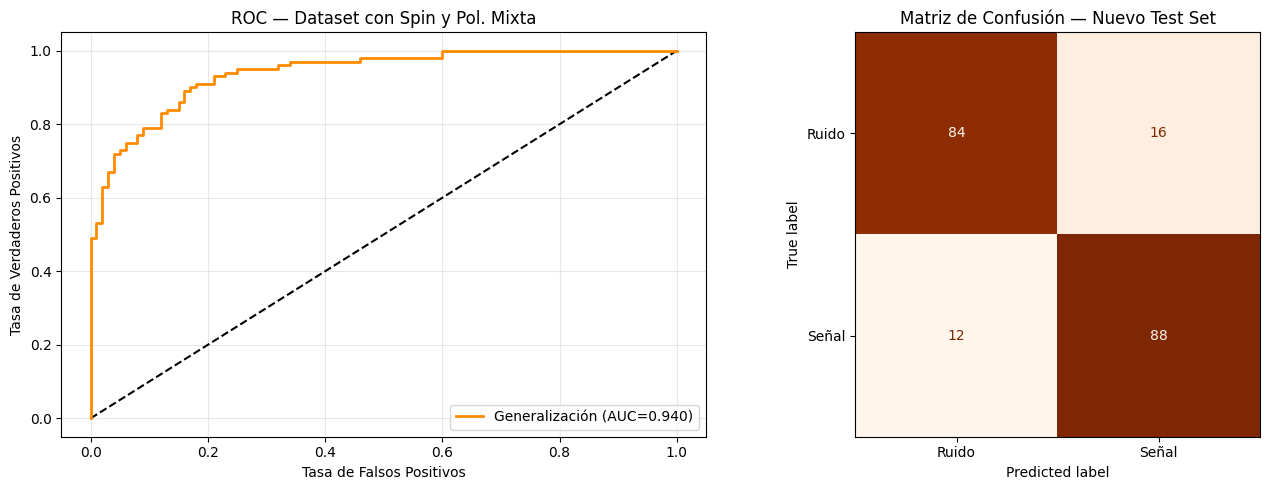


--- REPORTE (Dataset Generalización) ---
                 precision    recall  f1-score   support

      Ruido (0)       0.88      0.84      0.86       100
Señal+Ruido (1)       0.85      0.88      0.86       100

       accuracy                           0.86       200
      macro avg       0.86      0.86      0.86       200
   weighted avg       0.86      0.86      0.86       200



In [ ]:
NEW_PARAMS = {
    **PARAMS,                # heredamos todos los valores base
    # ── Nuevos rangos para el dataset de prueba ──────────────
    "snr_min"    : 3.0,      # SNR más bajo → problema más difícil
    "snr_max"    : 25.0,
    "spin_min"   : -0.95,    # rango de spin más amplio
    "spin_max"   :  0.95,
    "d_min"      : 50.0,     # distancias extremas
    "d_max"      : 1500.0,
    "use_spin"   : True,
}

def create_spin_test_dataset(n_elements, p=NEW_PARAMS, verbose=True):
    """
    Dataset de validación con spin y mezcla de polarizaciones aleatorias.
    No se usa para entrenar: sirve para medir generalización.
    """
    if verbose:
        print(f"Generando dataset de generalización ({n_elements} muestras)...")

    n_ruido, n_senal = n_elements // 2, n_elements - n_elements // 2
    X_list, y_list   = [], []
    fs = FS

    # Clase 0
    for _ in range(n_ruido):
        t_r  = random.uniform(p["window_min"], p["window_max"])
        sig  = random.uniform(p["sigma_min"],  p["sigma_max"])
        N    = int(t_r / p["delta_t"])
        t    = np.arange(N) * p["delta_t"]
        _, n = generate_noise(t, sigma=sig, add_glitch=np.random.rand() < p["glitch_prob"], p=p)
        _, _, spec = get_spectrogram(n, fs=fs, p=p)
        X_list.append(np.expand_dims(spec, -1)); y_list.append(0)

    # Clase 1 — spin y polarización aleatoria
    for _ in range(n_senal):
        snr  = random.uniform(p["snr_min"], p["snr_max"])
        d    = random.uniform(p["d_min"],   p["d_max"])
        f0   = random.uniform(p["f_lower_min"], p["f_lower_max"])
        s1z  = random.uniform(p["spin_min"], p["spin_max"])
        s2z  = random.uniform(p["spin_min"], p["spin_max"])
        mix  = np.random.rand() < 0.5          # 50 % usarán polarización mixta

        _, wave = generate_wave(distance=d, f_lower=f0, target_snr=snr,
                                delta_t=p["delta_t"], spin1z=s1z, spin2z=s2z,
                                use_spin=True, polarization_mix=mix, p=p)
        _, _, spec = get_spectrogram(wave, fs=fs, p=p)
        X_list.append(np.expand_dims(spec, -1)); y_list.append(1)

    # Padding
    max_w   = max(s.shape[1] for s in X_list)
    fixed_h = X_list[0].shape[0]
    X_arr   = np.zeros((len(X_list), fixed_h, max_w, 1), dtype='float32')
    for i, s in enumerate(X_list):
        X_arr[i, :s.shape[0], :s.shape[1], :] = s

    return X_arr, np.array(y_list, dtype='float32').reshape(-1, 1)


N_GEN = 200
X_gen, y_gen = create_spin_test_dataset(N_GEN)

# Normalizar con las estadísticas del entrenamiento original
X_gen_norm =normalize_subset(X_gen)

X_gen_t = torch.tensor(X_gen_norm, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
y_gen_t = torch.tensor(y_gen, dtype=torch.float32)

gen_loader = DataLoader(TensorDataset(X_gen_t, y_gen_t), batch_size=PARAMS["batch_size"])
_, gen_acc, gen_probs, gen_labels = evaluate(model, gen_loader, criterion, device)

print(f"\nAccuracy en dataset de generalización (spin + pol. mixta): {gen_acc*100:.2f}%")

# ── Confusion Matrix ──────────────────────────────────────────
y_gen_pred = (gen_probs >= 0.5).astype(int)
cm_gen = confusion_matrix(gen_labels.astype(int), y_gen_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr_g, tpr_g, _ = roc_curve(gen_labels, gen_probs)
auc_g = auc(fpr_g, tpr_g)
axes[0].plot([0,1],[0,1],'k--')
axes[0].plot(fpr_g, tpr_g, color='darkorange', lw=2,
             label=f'Generalización (AUC={auc_g:.3f})')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('ROC — Dataset con Spin y Pol. Mixta')
axes[0].legend(); axes[0].grid(alpha=0.3)

ConfusionMatrixDisplay(cm_gen, display_labels=["Ruido","Señal"]).plot(
    ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title('Matriz de Confusión — Nuevo Test Set')

plt.tight_layout(); plt.show()

print("\n--- REPORTE (Dataset Generalización) ---")
print(classification_report(gen_labels.astype(int), y_gen_pred,
                            target_names=["Ruido (0)","Señal+Ruido (1)"]))


## Bloque 13 — Test de Generalización con Morphologías Nuevas

Evaluamos señales **no vistas durante el entrenamiento**: chirps lineales y cuadráticos.

Chirp lineal   → P(señal) = 0.0000  ❌ No detectado
Chirp cuadrático → P(señal) = 0.0000  ❌ No detectado


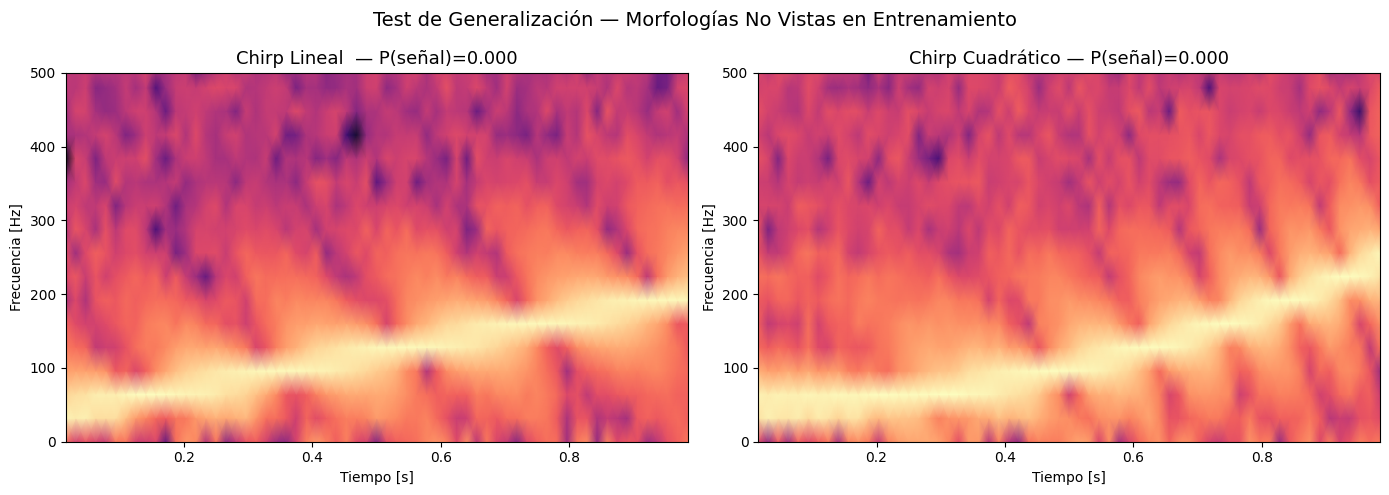

In [ ]:
def predict_single(data, model, mean_n, std_n, device, p=PARAMS):
    """Devuelve la probabilidad de ser señal para una única serie temporal."""
    _, _, spec = get_spectrogram(data, fs=FS, p=p)
    X = np.expand_dims(spec, axis=(0, -1)).astype('float32')
    X = (X - mean_n) / std_n
    Xt = torch.tensor(X).permute(0, 3, 1, 2).to(device)
    model.eval()
    with torch.no_grad():
        return model(Xt).item()


# ── Chirp lineal ─────────────────────────────────────────────
t_vis = np.linspace(0, 1, FS)
sig_lin  = sp_signal.chirp(t_vis, f0=40, f1=200, t1=1, method='linear')
sig_lin  = sig_lin / (np.std(sig_lin) + 1e-8)
_, noise_a = generate_noise(t_vis, sigma=1e-21)
data_lin  = noise_a + 12 * 1e-21 * sig_lin
mean_lin, std_lin = float(np.mean(data_lin)), float(np.std(data_lin))

# ── Chirp cuadrático ──────────────────────────────────────────
sig_quad = sp_signal.chirp(t_vis, f0=50, f1=250, t1=1, method='quadratic')
sig_quad = sig_quad / (np.std(sig_quad) + 1e-8)
_, noise_b = generate_noise(t_vis, sigma=1e-21)
data_quad = noise_b + 12 * 1e-21 * sig_quad
mean_quad, std_quad = float(np.mean(data_quad)), float(np.std(data_quad))

# ── Predicciones ─────────────────────────────────────────────
p_lin  = predict_single(data_lin,  model, mean_lin, std_lin, device)
p_quad = predict_single(data_quad, model, mean_quad, std_quad, device)

print(f"Chirp lineal   → P(señal) = {p_lin:.4f}  {'✅ Detectado' if p_lin > 0.5 else '❌ No detectado'}")
print(f"Chirp cuadrático → P(señal) = {p_quad:.4f}  {'✅ Detectado' if p_quad > 0.5 else '❌ No detectado'}")

# ── Espectrogramas de las morfologías nuevas ──────────────────
_, t_sl, spec_lin  = get_spectrogram(data_lin)
_, t_sq, spec_quad = get_spectrogram(data_quad)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pcolormesh(t_sl, np.linspace(0, FS//2, spec_lin.shape[0]),
                   spec_lin, shading='gouraud', cmap='magma')
axes[0].set_title(f'Chirp Lineal  — P(señal)={p_lin:.3f}', fontsize=13)
axes[0].set_xlabel('Tiempo [s]'); axes[0].set_ylabel('Frecuencia [Hz]')
axes[0].set_ylim(0, 500)

axes[1].pcolormesh(t_sq, np.linspace(0, FS//2, spec_quad.shape[0]),
                   spec_quad, shading='gouraud', cmap='magma')
axes[1].set_title(f'Chirp Cuadrático — P(señal)={p_quad:.3f}', fontsize=13)
axes[1].set_xlabel('Tiempo [s]'); axes[1].set_ylabel('Frecuencia [Hz]')
axes[1].set_ylim(0, 500)

plt.suptitle('Test de Generalización — Morfologías No Vistas en Entrenamiento',
             fontsize=14)
plt.tight_layout(); plt.show()


Bloque 14-A — Comparación con Matched Filtering (Caso ideal para MF)

Calibrando ruido de fondo de forma autónoma para la CNN...

🔬 BLOQUE 14-A — MF DOMINA (EXACTITUD VS SNR)
Threshold MF (99th percentile): 0.0000

SNR  | MF Acc  | CNN Acc
------------------------------
 1.0 |  100.0% |   50.0%
 2.0 |   99.0% |   50.0%
 3.0 |   99.0% |   50.0%
 4.0 |  100.0% |   50.0%
 6.0 |   99.0% |   50.0%
 8.0 |  100.0% |   50.0%
10.0 |  100.0% |   50.0%
15.0 |   99.0% |   50.0%
20.0 |  100.0% |   50.0%
30.0 |   97.0% |   50.0%
50.0 |  100.0% |   50.0%
100.0 |  100.0% |   50.0%


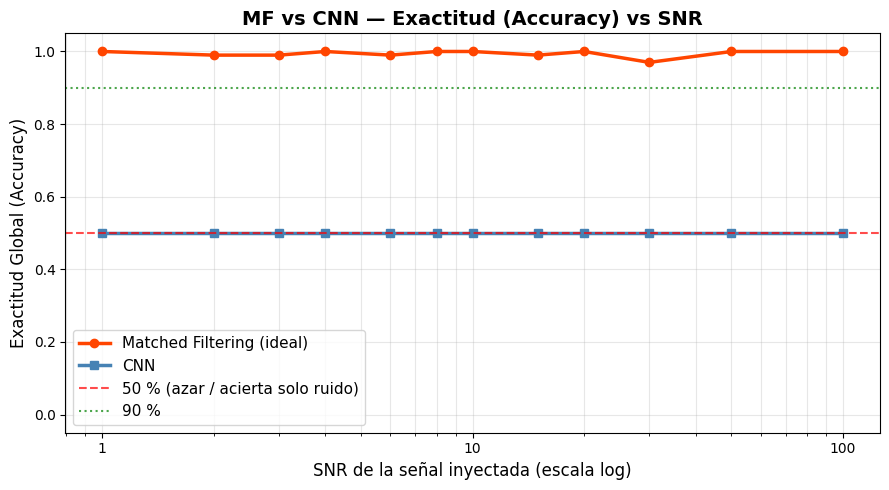

In [ ]:
'''
No es posible hacer una comparación estrictamente “justa” entre CNN y matched filtering porque
ambos métodos asumen cosas distintas: el MF es óptimo solo bajo un modelo estadístico del ruido
perfectamente conocido y una señal parametrizada exacta, mientras que la CNN aprende directamente
de datos y depende del dominio de entrenamiento. Por ello, en estos bloques 14 no se busca una igualdad
estricta, sino ilustrar su comportamiento en dos regímenes complementarios: un caso ideal donde MF es
teóricamente óptimo, y un caso más realista donde aparecen desviaciones del modelo (ruido no ideal,
glitches y variabilidad), para evidenciar las diferencias de robustez entre ambos enfoques.
'''
# ============================================================
# 🔬 BLOQUE 14-A — MATCHED FILTERING DOMINA (IDEAL) - EXACTITUD
# ============================================================

fs = FS
window_max = PARAMS["window_max"]
N_target = int(fs * window_max)

# --------------------------------------------------------
# 0. Calibración Independiente para la CNN
# --------------------------------------------------------
def get_dynamic_noise_calibration_b14(n_samples=200, p=PARAMS):
    """Genera ruido de fondo puro estilo Bloque 10 para extraer media y std."""
    noise_pixels = []
    for _ in range(n_samples):
        t_rand   = random.uniform(p["window_min"], p["window_max"])
        sig_rand = random.uniform(p["sigma_min"],  p["sigma_max"])
        times    = np.arange(int(t_rand / p["delta_t"])) * p["delta_t"]

        _, pure_noise = generate_noise(times, sigma=sig_rand, add_glitch=False, p=p)
        _, _, spec = get_spectrogram(pure_noise, fs=FS, p=p)
        noise_pixels.append(spec.flatten())

    concat_noise = np.concatenate(noise_pixels)
    return float(np.mean(concat_noise)), float(np.std(concat_noise))

print("Calibrando ruido de fondo de forma autónoma para la CNN...")
dyn_mean, dyn_std = get_dynamic_noise_calibration_b14()


def cnn_predict_timeseries(x, model, baseline_mean, baseline_std, device):
    """Evalúa con la CNN aplicando padding seguro y normalización independiente."""
    _, _, spec = get_spectrogram(x, fs=FS, p=PARAMS)
    X = np.expand_dims(spec, axis=(0, -1)).astype('float32')

    fixed_h = X_tr_t.shape[2]
    max_w   = X_tr_t.shape[3]
    X_pad = np.zeros((1, fixed_h, max_w, 1), dtype='float32')

    h_fit = min(spec.shape[0], fixed_h)
    w_fit = min(spec.shape[1], max_w)
    X_pad[0, :h_fit, :w_fit, 0] = spec[:h_fit, :w_fit]

    X_pad = (X_pad - baseline_mean) / (baseline_std + 1e-10)
    Xt = torch.tensor(X_pad).permute(0,3,1,2).to(device)

    model.eval()
    with torch.no_grad():
        prob = model(Xt).item()

    return prob


# ------------------------------------------------------------
# 1. Template Fijo y Generación de Datos (Física del Bloque 10)
# ------------------------------------------------------------
def get_fixed_waveform():
    """Plantilla exacta (m1=30, m2=25) para que el MF sea el detector óptimo."""
    hp, _ = get_td_waveform(
        approximant="IMRPhenomD", mass1=30, mass2=25,
        distance=500, delta_t=1/fs, f_lower=20
    )
    h = np.array(hp)[np.array(hp.sample_times) <= 0.0]
    if len(h) > N_target:
        h = h[-N_target:]
    return h

h_template = get_fixed_waveform()

def generate_ideal_signal(snr_target, p=PARAMS):
    """Genera ruido y señal aplicando estrictamente la matemática del Bloque 10."""
    h_arr = get_fixed_waveform()

    # Lógica de SNR del Bloque 10 (la onda es fija, el ruido varía)
    if snr_target == 0:
        sigma_calc = p["sigma_max"]
    else:
        energia = np.sqrt(np.sum(h_arr**2))
        sigma_calc = energia / snr_target

    times = np.arange(N_target) * p["delta_t"]

    # Ruido blanco gaussiano (igual que en el entrenamiento)
    _, noise = generate_noise(times, sigma=sigma_calc, add_glitch=False, p=p)

    x = noise.copy()
    if snr_target > 0:
        start_idx = N_target - len(h_arr) # Alineado al final
        x[start_idx:] += h_arr

    return x

def mf_optimal(x, h):
    """
    Matched filter mediante correlación cruzada.
    Al ser el ruido blanco gaussiano, este método es matemáticamente óptimo.
    """
    x_norm = normalize_subset(x)
    h_norm = normalize_subset(h)
    correlation = np.correlate(x_norm, h_norm, mode='full')
    return np.max(correlation) / np.sqrt(len(h))


print("\n" + "="*60)
print("🔬 BLOQUE 14-A — MF DOMINA (EXACTITUD VS SNR)")
print("="*60)

# Threshold MF (usando ruido puro SNR=0 para medir la falsas alarmas)
noise_vals = [mf_optimal(generate_ideal_signal(0), h_template) for _ in range(300)]
thr = np.percentile(noise_vals, 99)

print(f"Threshold MF (99th percentile): {thr:.4f}")

snrs = [1, 2, 3, 4, 6, 8, 10, 15, 20, 30, 50, 100]

mf_acc  = []
cnn_acc = []

print("\nSNR  | MF Acc  | CNN Acc")
print("-" * 30)

n_samples_per_class = 50

for snr in snrs:
    correct_mf  = 0
    correct_cnn = 0

    # ---- EVALUACIÓN CLASE 0 (Solo Ruido) ----
    for _ in range(n_samples_per_class):
        x = generate_ideal_signal(0) # SNR 0 = Solo ruido

        if mf_optimal(x, h_template) <= thr:
            correct_mf += 1

        prob = cnn_predict_timeseries(x, model, dyn_mean, dyn_std, device)
        if prob <= 0.5:
            correct_cnn += 1

    # ---- EVALUACIÓN CLASE 1 (Señal + Ruido) ----
    for _ in range(n_samples_per_class):
        x = generate_ideal_signal(snr) # Onda inyectada con el SNR correcto

        if mf_optimal(x, h_template) > thr:
            correct_mf += 1

        prob = cnn_predict_timeseries(x, model, dyn_mean, dyn_std, device)
        if prob > 0.5:
            correct_cnn += 1

    mf_val  = correct_mf / (n_samples_per_class * 2)
    cnn_val = correct_cnn / (n_samples_per_class * 2)

    mf_acc.append(mf_val)
    cnn_acc.append(cnn_val)

    print(f"{snr:4.1f} | {mf_val*100:6.1f}% | {cnn_val*100:6.1f}%")

# 📊 GRÁFICA
plt.figure(figsize=(9,5))
plt.plot(snrs, mf_acc,  marker='o', label="Matched Filtering (ideal)", color="orangered", lw=2.5)
plt.plot(snrs, cnn_acc, marker='s', label="CNN", color="steelblue", lw=2.5)

plt.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50 % (azar / acierta solo ruido)')
plt.axhline(0.9, color='green', linestyle=':', alpha=0.7, label='90 %')

plt.xscale('log')
plt.gca().xaxis.set_major_formatter(mticker.ScalarFormatter())
plt.ylim(-0.05, 1.05)
plt.xlabel("SNR de la señal inyectada (escala log)", fontsize=12)
plt.ylabel("Exactitud Global (Accuracy)", fontsize=12)
plt.title("MF vs CNN — Exactitud (Accuracy) vs SNR", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Bloque 14-B — Comparación con Matched Filtering (Caso ideal para CNN)

Calibrando ruido de fondo de forma autónoma para la CNN...

🔬 BLOQUE 14-B — CNN DOMINA (EXACTITUD VS SNR)
Threshold MF (99th percentile): 0.0000

SNR  | MF Acc  | CNN Acc
------------------------------
 1.0 |   48.0% |   50.0%
 2.0 |   50.0% |   50.0%
 3.0 |   50.0% |   50.0%
 4.0 |   50.0% |   51.0%
 6.0 |   50.0% |   50.0%
 8.0 |   49.0% |   51.0%
10.0 |   49.0% |   51.0%
15.0 |   50.0% |   55.0%
20.0 |   50.0% |   59.0%
30.0 |   50.0% |   62.0%
50.0 |   49.0% |   68.0%
100.0 |   49.0% |   67.0%


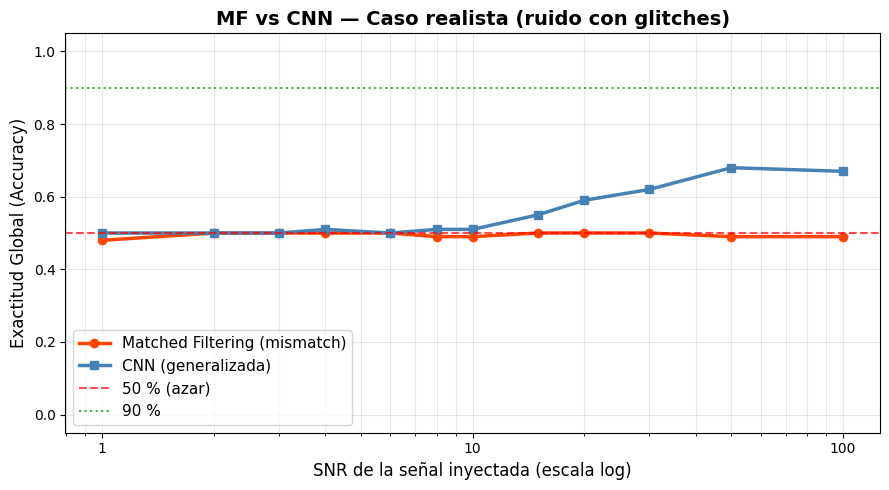

In [ ]:
# ============================================================
# 🔬 BLOQUE 14-B — CNN DOMINA (REALISTA) - EXACTITUD
# ============================================================

'''
En este bloque se simula un escenario más realista donde la señal puede presentar
variaciones respecto al modelo ideal y el ruido contiene artefactos no gaussianos
(glitches instrumentales). Este régimen evidencia las diferencias de robustez
entre ambos enfoques. Mediremos la Exactitud Global (Accuracy).
'''

# Usamos la frecuencia de muestreo global y la duración máxima de PARAMS
fs = FS
window_max = PARAMS["window_max"]
N_target = int(window_max / PARAMS["delta_t"])

# --------------------------------------------------------
# 0. Calibración Independiente para la CNN
# --------------------------------------------------------
def get_dynamic_noise_calibration_b14(n_samples=200, p=PARAMS):
    """Genera ruido de fondo puro para extraer media y std globales autónomos."""
    noise_pixels = []
    for _ in range(n_samples):
        t_rand   = random.uniform(p["window_min"], p["window_max"])
        sig_rand = random.uniform(p["sigma_min"],  p["sigma_max"])
        times    = np.arange(int(t_rand / p["delta_t"])) * p["delta_t"]
        add_gl   = np.random.rand() < p["glitch_prob"]

        _, pure_noise = generate_noise(times, sigma=sig_rand, add_glitch=add_gl, p=p)
        _, _, spec = get_spectrogram(pure_noise, fs=FS, p=p)
        noise_pixels.append(spec.flatten())

    concat_noise = np.concatenate(noise_pixels)
    return float(np.mean(concat_noise)), float(np.std(concat_noise))

print("Calibrando ruido de fondo de forma autónoma para la CNN...")
dyn_mean, dyn_std = get_dynamic_noise_calibration_b14()

def cnn_predict_timeseries(x, model, baseline_mean, baseline_std, device):
    """Convierte serie temporal en espectrograma y evalúa con la CNN normalizando."""
    _, _, spec = get_spectrogram(x, fs=FS, p=PARAMS)
    X = np.expand_dims(spec, axis=(0, -1)).astype('float32')

    fixed_h = X_tr_t.shape[2]
    max_w   = X_tr_t.shape[3]
    X_pad = np.zeros((1, fixed_h, max_w, 1), dtype='float32')

    # CORRECCIÓN: Tomamos el mínimo entre el tamaño real y el máximo permitido
    # Esto evita el error de dimensiones si el espectrograma es 1 píxel más grande
    h_fit = min(spec.shape[0], fixed_h)
    w_fit = min(spec.shape[1], max_w)

    X_pad[0, :h_fit, :w_fit, 0] = spec[:h_fit, :w_fit]

    # Normalización con el fondo calibrado independiente
    X_pad = (X_pad - baseline_mean) / (baseline_std + 1e-10)
    Xt = torch.tensor(X_pad).permute(0,3,1,2).to(device)

    model.eval()
    with torch.no_grad():
        prob = model(Xt).item()

    return prob

def noise_glitch():
    """Genera ruido realista con glitches instrumentales."""
    _, x = generate_wave(target_snr=0, p=PARAMS)

    # Igualar tamaño ANTES del glitch
    if len(x) < N_target:
        x = np.pad(x, (0, N_target - len(x)))
    else:
        x = x[:N_target]

    if np.random.rand() < PARAMS["glitch_prob"]:
        t = np.arange(N_target) * PARAMS["delta_t"]
        glitch = generate_glitch(t, sigma=np.std(x), p=PARAMS)
        x = x + glitch

    return x

def mf_simple(x, h):
    """Versión simplificada del matched filtering (ingenuo)."""
    x = x[:N_target]
    h = h[:N_target]

    # Normalizar usando la función original
    x = normalize_subset(x)
    h = normalize_subset(h)

    X = np.fft.rfft(x)
    H = np.fft.rfft(h)
    return np.max(np.real(np.fft.irfft(X * np.conj(H))))

print("\n" + "="*60)
print("🔬 BLOQUE 14-B — CNN DOMINA (EXACTITUD VS SNR)")
print("="*60)

# Aseguramos que el template tenga también la misma longitud N_target
template = generate_template()
if len(template) < N_target:
    template = np.pad(template, (0, N_target - len(template)))
else:
    template = template[:N_target]

# Threshold MF en ruido REALISTA
thr = np.percentile([mf_simple(noise_glitch(), template) for _ in range(300)], 99)
print(f"Threshold MF (99th percentile): {thr:.4f}")

snrs = [1, 2, 3, 4, 6, 8, 10, 15, 20, 30, 50, 100]

mf_acc  = []
cnn_acc = []

print("\nSNR  | MF Acc  | CNN Acc")
print("-" * 30)

n_samples_per_class = 50

for snr in snrs:
    correct_mf  = 0
    correct_cnn = 0

    # ---- EVALUACIÓN CLASE 0 (Solo Ruido + Glitches) ----
    for _ in range(n_samples_per_class):
        x = noise_glitch()

        if mf_simple(x, template) <= thr:
            correct_mf += 1

        prob = cnn_predict_timeseries(x, model, dyn_mean, dyn_std, device)
        if prob <= 0.5:
            correct_cnn += 1

    # ---- EVALUACIÓN CLASE 1 (Señal + Ruido + Glitches) ----
    for _ in range(n_samples_per_class):
        _, x = generate_wave(target_snr=snr, p=PARAMS)

        # Ajustar tamaño ANTES de sumar el glitch
        if len(x) < N_target:
            x = np.pad(x, (0, N_target - len(x)))
        else:
            x = x[:N_target]

        if np.random.rand() < PARAMS["glitch_prob"]:
            t = np.arange(N_target) * PARAMS["delta_t"]
            glitch = generate_glitch(t, sigma=np.std(x), p=PARAMS)
            x = x + glitch

        if mf_simple(x, template) > thr:
            correct_mf += 1

        prob = cnn_predict_timeseries(x, model, dyn_mean, dyn_std, device)
        if prob > 0.5:
            correct_cnn += 1

    # Exactitud = Total de Aciertos / Total de Muestras
    mf_val  = correct_mf / (n_samples_per_class * 2)
    cnn_val = correct_cnn / (n_samples_per_class * 2)

    mf_acc.append(mf_val)
    cnn_acc.append(cnn_val)

    print(f"{snr:4.1f} | {mf_val*100:6.1f}% | {cnn_val*100:6.1f}%")

# 📊 GRÁFICA
plt.figure(figsize=(9,5))
plt.plot(snrs, mf_acc,  marker='o', label="Matched Filtering (mismatch)", color="orangered", lw=2.5)
plt.plot(snrs, cnn_acc, marker='s', label="CNN (generalizada)", color="steelblue", lw=2.5)

plt.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='50 % (azar)')
plt.axhline(0.9, color='green', linestyle=':', alpha=0.7, label='90 %')

plt.xscale('log')
plt.gca().xaxis.set_major_formatter(mticker.ScalarFormatter())
plt.ylim(-0.05, 1.05)
plt.xlabel("SNR de la señal inyectada (escala log)", fontsize=12)
plt.ylabel("Exactitud Global (Accuracy)", fontsize=12)
plt.title("MF vs CNN — Caso realista (ruido con glitches)", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()